# compile value-added catalog for DESI-LOWZ

In [1]:
import os
import glob
import torch
import numpy as np
from astropy.table import Table as aT
from astropy.cosmology import Cosmology, Planck13

In [2]:
from sedflow import flows as F
from sedflow import galaxy as G

/home/chhahn/.conda/envs/gqp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
import corner as DFM
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [4]:
if torch.cuda.is_available(): device = 'cuda'
else: device = 'cpu'

# import flows
gsed = G.ModelB(name='modelb.lowz', device=device)
desiflow = F.DESIflow(gsed=gsed, device=device)

/home/chhahn/projects/SEDflow/src/sedflow/flows.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.flow = torch.load(fqphi, map_location=self.device)


In [5]:
lowz = aT.read('/tigress/chhahn/sedflow/alexamon_lowz/LOWZ_z_photometry.csv')

In [10]:
lowz['logmstar_median'] = np.repeat(-999., len(lowz))
lowz['sigma_logmstar'] = np.repeat(-999., len(lowz))
for igal in np.arange(len(lowz)): 
    fpost = os.path.join('/tigress/chhahn/sedflow/alexamon_lowz/',
                         'desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.%i.npy' % igal)
    if os.path.isfile(fpost): 
        try: 
            post = np.load(fpost)
        except: 
            print('%s has issues' % fpost)
        tage = Planck13.age(lowz['Z'][igal]).value # age in Gyr
        
        # below is to correct for the fact that I forgot to switch log10(Z) to Z
        post[:,7:9] = 10**post[:,7:9] 

        # calculate surviving stellar mass
        logmstar = gsed._msurv(post, np.repeat(tage, post.shape[0]))
        
        lowz['logmstar_median'][igal] = np.median(logmstar)
        lowz['sigma_logmstar'][igal] = np.std(logmstar)
    else: 
        print('%s does not exist' % fpost)
        
    if igal % 10000:
        lowz.write('/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.vagc.hdf5', format='hdf5', overwrite=True)

/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.0.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.1.npy does not exist


/home/chhahn/.conda/envs/gqp/lib/python3.11/site-packages/astropy/io/misc/hdf5.py:281: UserWarning: table path was not set via the path= argument; using default path __astropy_table__
  warnings.warn(


/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.2.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.3.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.4.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.5.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.6.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.7.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.8.npy does not exist


/home/chhahn/projects/SEDflow/src/sedflow/galaxy.py:253: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self._msurv_nmf_emu = torch.load(os.path.join(
/home/chhahn/projects/S

/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.12.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.13.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.18.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.22.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.30.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.43.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.44.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.48.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.52.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.53

/home/chhahn/projects/SEDflow/src/sedflow/galaxy.py:111: RuntimeWarning: invalid value encountered in divide
  tt_u[:,i] = 1. - (tt[:,i] / np.prod(tt_u[:,:i], axis=1))


/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.5080.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.5093.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.5095.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.5098.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.5102.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.5104.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.5105.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.5108.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.5119.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.l


KeyboardInterrupt



/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.814.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.817.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.820.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.827.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.829.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.838.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.844.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.848.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.grzW1W2.854.npy does not exist
/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.modelb.lowz.cdf.g

In [15]:
lowz.write('/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.vagc.hdf5', format='hdf5', overwrite=True)

# posterior sanity check

In [5]:
lowz = aT.read('/tigress/chhahn/sedflow/alexamon_lowz/desi_lowz.sedflow.vagc.hdf5')

In [13]:
lowz

DESI_TARGET,TARGETID,Z,FLUX_W1,FLUX_W2,FLUX_W3,FLUX_W4,FLUX_IVAR_W1,FLUX_IVAR_W2,FLUX_IVAR_W3,FLUX_IVAR_W4,MAG_R,MAG_R_ERR,MAG_G,MAG_G_ERR,MAG_Z,MAG_Z_ERR,logmstar_median,sigma_logmstar
int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
4611686018427387904,2267128157700097,0.03110001061038468,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.550903514829866,0.014660058565197366,20.063104105293387,0.011503651684076388,19.44373204002007,0.043273442333195467,-999.0,-999.0
4611686018427387904,2267132943400961,0.0547667397092142,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.628329021925644,0.01746791678788527,20.033670613737243,0.011267399024248807,19.6607372557575,0.04110368080687674,-999.0,-999.0
4611686018427387904,2267168028753921,0.022987389705772042,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.720025899238184,0.0252102831926281,19.969890505911998,0.015365632073806363,19.53861311237496,0.04001991463090452,-999.0,-999.0
4611686018427387904,2271525801558028,0.22219074965843683,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.913343126033777,0.030840058687517487,21.394349855798833,0.024310194171184737,20.934833167149435,0.06404382219929651,-999.0,-999.0
4611686018427387904,2271541295316994,0.1584443469630328,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.622527979640182,0.02445706212336672,21.1585007389924,0.01967434534065528,20.374051744594222,0.054687609810500845,-999.0,-999.0
4611686018427387904,2271545963577344,0.0996845241050366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.714412719184455,0.029615302986959854,20.91516721251483,0.0182917373309271,20.63803011096995,0.04969164049813552,-999.0,-999.0
4611686018427387904,2275924212973581,0.37812517146448693,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.990302009527042,0.01935658407940227,21.543847378809406,0.022170120549488574,21.038697572411984,0.04150362029875703,-999.0,-999.0
4611686018427387904,2275928403083273,0.039982058551552124,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.815747727932518,0.01047237260038872,20.32174982674902,0.010279431087468474,19.64742090964686,0.01932421234612303,-999.0,-999.0
4611686018427387904,2275959113777162,0.12470979669494867,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.221117510046863,0.006452163538102803,19.59434010315296,0.004848958036145144,19.05144617571652,0.013975175346162477,-999.0,-999.0


Text(0, 0.5, '$\\log M_*$')

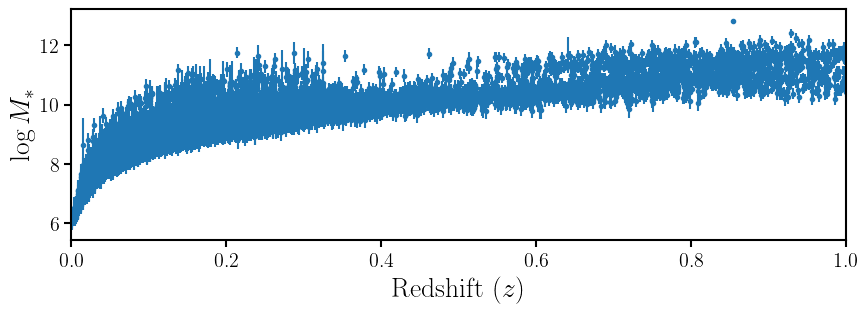

In [15]:
fig = plt.figure(figsize=(10,3))
sub = fig.add_subplot(111)

has_mstar = (lowz['logmstar_median'] > 0.)
sub.errorbar(lowz['Z'][has_mstar], lowz['logmstar_median'][has_mstar], yerr=lowz['sigma_logmstar'][has_mstar], fmt='.C0')
sub.set_xlabel('Redshift ($z$)', fontsize=20)
sub.set_xlim(0., 1.)
sub.set_ylabel('$\log M_*$', fontsize=20)